In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import keras
import glob
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json
from skimage.metrics import peak_signal_noise_ratio as PSNR
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.layers import Dense
#from sewar.full_ref import uqi
import sys

In [10]:
#gray = True
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)#read ima

Mounted at /content/gdrive/


In [3]:
import cv2
import numpy as np
import glob

inPath = "/content/gdrive/MyDrive/flipped/input/*.jpg"
outPath = "/content/gdrive/MyDrive/flipped/output/*.jpg"

def loadImages(path):
    imgList = []
    for img in glob.glob(path):
        image = cv2.imread(img)
        normalized_img = image.astype(np.float32) / 255.0
        imgList.append(normalized_img)

    npImg = np.asarray(imgList, dtype=np.float32)
    return npImg

inputDS = loadImages(inPath)
outputDS = loadImages(outPath)

print(inputDS.shape)
print(outputDS.shape)

(25000, 128, 128, 3)
(25000, 128, 128, 3)


In [26]:
# Split Data into train and validation and test
trainInput = inputDS[0:20000]
valInput = inputDS[20000:24000]
testInput = inputDS[24000:25000]

trainOutput = outputDS[0:20000]
valOutput = outputDS[20000:24000]
testOutput = outputDS[24000:25000]

# Verify the new shapes
print(trainInput.shape)
print(valInput.shape)
print(testInput.shape)
print(trainOutput.shape)
print(valOutput.shape)
print(testOutput.shape)

(20000, 128, 128, 3)
(4000, 128, 128, 3)
(1000, 128, 128, 3)
(20000, 128, 128, 3)
(4000, 128, 128, 3)
(1000, 128, 128, 3)


In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define a basic residual block
def residual_block(x, filters, kernel_size=3, stride=1, padding='same'):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding=padding, activation='relu')(x)
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding=padding)(x)
    x = layers.BatchNormalization()(x)

    # Add 1x1 convolution to match the number of channels if necessary
    if shortcut.shape[-1] != x.shape[-1]:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding=padding)(shortcut)

    x = layers.Add()([x, shortcut])  # Skip connection
    x = layers.Activation('relu')(x)
    return x

# Define the U-Net model architecture with residual blocks, excluding the bottleneck
def build_unet_with_resnet(input_shape=(128, 128, 3), dropout_rate=0.2, l2_reg=1e-5):
    inputs = keras.Input(shape=input_shape)

    # Encoder
    conv1 = residual_block(inputs, 32)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)

    conv2 = residual_block(pool1, 64)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)

    conv3 = residual_block(pool2, 128)
    pool3 = layers.MaxPooling2D((2, 2))(conv3)

    conv4 = residual_block(pool3, 256)
    pool4 = layers.MaxPooling2D((2, 2))(conv4)

    conv5 = residual_block(pool4, 512)
    pool4 = layers.MaxPooling2D((2, 2))(conv5)

    # Middle (Bottleneck) without residual block
    convm = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(pool4)
    convm = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(convm)
    # Decoder with adjusted upsampling factors for (256, 256) output size
    deconv5 = layers.Conv2DTranspose(512, (3, 3), strides=(2, 2), padding='same')(convm)
    uconv5 = layers.concatenate([deconv5, conv5])
    uconv5 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(uconv5)
    uconv5 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(uconv5)

    deconv4 = layers.Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(uconv5)
    uconv4 = layers.concatenate([deconv4, conv4])
    uconv4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(uconv4)
    uconv4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(uconv4)

    deconv3 = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(uconv4)
    uconv3 = layers.concatenate([deconv3, conv3])
    uconv3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(uconv3)
    uconv3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(uconv3)

    deconv2 = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(uconv3)
    uconv2 = layers.concatenate([deconv2, conv2])
    uconv2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(uconv2)
    uconv2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(uconv2)

    deconv1 = layers.Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(uconv2)
    uconv1 = layers.concatenate([deconv1, conv1])
    uconv1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(uconv1)
    uconv1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(uconv1)

    deconv_output = layers.Conv2DTranspose(3, (3, 3), strides=(1, 1), padding='same')(uconv1)

    outputs = layers.Activation('sigmoid')(deconv_output)

    model = keras.Model(inputs, outputs)

    # Compile the model with MSE loss
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

# Create the model
model = build_unet_with_resnet()
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d_27 (Conv2D)          (None, 128, 128, 32)         896       ['input_2[0][0]']             
                                                                                                  
 conv2d_28 (Conv2D)          (None, 128, 128, 32)         9248      ['conv2d_27[0][0]']           
                                                                                                  
 batch_normalization_5 (Bat  (None, 128, 128, 32)         128       ['conv2d_28[0][0]']           
 chNormalization)                                                                           

In [6]:
# Train the model using the loaded weights
history = model.fit(trainInput, trainOutput,
                          epochs=200,
                          batch_size=64,
                          shuffle=True,
                          validation_data=(valInput, valOutput),
                          verbose=1)

Epoch 1/200
344/344 [==============================] - 49s 105ms/step - loss: 0.0116 - val_loss: 0.0087
Epoch 2/200
344/344 [==============================] - 29s 86ms/step - loss: 0.0090 - val_loss: 0.0085
Epoch 3/200
344/344 [==============================] - 30s 86ms/step - loss: 0.0084 - val_loss: 0.0078
Epoch 4/200
344/344 [==============================] - 30s 86ms/step - loss: 0.0079 - val_loss: 0.0075
Epoch 5/200
344/344 [==============================] - 30s 86ms/step - loss: 0.0074 - val_loss: 0.0072
Epoch 6/200
344/344 [==============================] - 29s 86ms/step - loss: 0.0075 - val_loss: 0.0069
Epoch 7/200
344/344 [==============================] - 30s 86ms/step - loss: 0.0071 - val_loss: 0.0066
Epoch 8/200
344/344 [==============================] - 29s 86ms/step - loss: 0.0069 - val_loss: 0.0068
Epoch 9/200
344/344 [==============================] - 30s 86ms/step - loss: 0.0067 - val_loss: 0.0068
Epoch 10/200
344/344 [==============================] - 29s 86ms/step - 

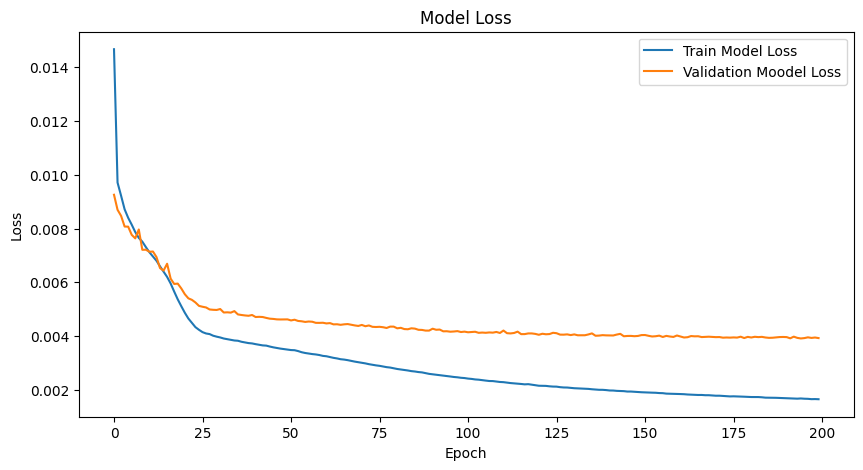

In [8]:
# Plot MSE loss and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Model Loss')
plt.plot(history.history['val_loss'], label='Validation Moodel Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have defined valInput, generated_images, and valOutput elsewhere

def stretch_contrast(image):
    # Apply contrast stretching
    min_val = np.min(image)
    max_val = np.max(image)
    stretched_image = (image - min_val) / (max_val - min_val)
    return stretched_image

indices_to_preview = [799, 796, 699, 802]  # Update with the indices you want

# Display original, generated, and ground truth images
plt.figure(figsize=(4, 2 * len(indices_to_preview)))

for idx, i in enumerate(indices_to_preview, start=1):

    # Original Image (Grayscale)
    plt.subplot(len(indices_to_preview), 3, idx * 3 - 2)
    original_image = valInput[i].squeeze()
    original_image = np.mean(original_image, axis=-1)  # Convert to grayscale
    plt.imshow(original_image, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Generated Image with Contrast Stretching
    plt.subplot(len(indices_to_preview), 3, idx * 3 - 1)
    generated_image = generated_images[i].squeeze()
    stretched_generated_image = stretch_contrast(generated_image)
    plt.imshow(stretched_generated_image)
    plt.title('Generated ')
    plt.axis('off')

    # Ground Truth Image
    plt.subplot(len(indices_to_preview), 3, idx * 3)
    ground_truth_image = valOutput[i].squeeze()
    plt.imshow(ground_truth_image)
    plt.title('Ground Truth')
    plt.axis('off')

plt.tight_layout()
plt.show()